Hello, my name is Alex Mattei and this is my first homework assignment for Data Visualization. Here, we'll be making some visualizations from data of our choice to work with some Python functions to observe how graphs can effectively (or not) illustrate some kind of trend or story from raw numbers.

For this assignment, the data I'm choosing requires a bit of context. I work with GW Baseball as a student analytics manager, and one of our tasks is attending home games and "tagging them", which involves tracking the game outcomes using a digital software that receives data from a high speed camera behind home plate. We tag every pitch with a type and outcome, and after every game we receive a spreadsheet that lists lots of important data points for every single pitch of the game. For this assignment, I'll be using one of those spreadsheets.

We'll start by setting up our libraries, importing the data, and likely downsizing it as it is a very wide spreadsheet.

In [20]:
import seaborn as sds
import matplotlib.pyplot as mat
import pandas as pd

In [10]:
baseball_data = pd.read_csv("hw2baseballdata.csv")

Index(['PitchNo', 'Date', 'Time', 'PAofInning', 'PitchofPA', 'Pitcher',
       'PitcherId', 'PitcherThrows', 'PitcherTeam', 'Batter',
       ...
       'ThrowTrajectoryZc1', 'ThrowTrajectoryZc2', 'PitchReleaseConfidence',
       'PitchLocationConfidence', 'PitchMovementConfidence',
       'HitLaunchConfidence', 'HitLandingConfidence',
       'CatcherThrowCatchConfidence', 'CatcherThrowReleaseConfidence',
       'CatcherThrowLocationConfidence'],
      dtype='str', length=167)


Let's cut down our data by selecting some specifically valuable columns that might be on interest for our graphing.

In [17]:
baseball_simple = baseball_data[['PitchNo', 'Balls', 'Strikes', 'TaggedPitchType', 'PitchCall', 
    'TaggedHitType', 'PlayResult', 'RelSpeed', 'SpinRate', 'InducedVertBreak', 'HorzBreak']]

baseball_simple

,PitchNo,Balls,Strikes,TaggedPitchType,PitchCall,TaggedHitType,PlayResult,RelSpeed,SpinRate,InducedVertBreak,HorzBreak
0,1,0,0,Fastball,BallCalled,Undefined,Undefined,87.06319,1995.096563,14.55965,1.97945
1,2,1,0,Slider,FoulBallNotFieldable,Undefined,Undefined,81.10267,2553.955738,9.73524,-9.25634
2,3,1,1,Fastball,InPlay,FlyBall,Out,88.75522,2003.088098,15.72147,5.20079
3,4,0,0,Slider,StrikeCalled,Undefined,Undefined,80.13681,2397.460917,8.57083,-13.89930
4,5,0,1,Slider,FoulBallNotFieldable,Undefined,Undefined,80.10726,2563.670148,6.99870,-10.32012
...,...,...,...,...,...,...,...,...,...,...,...
289,290,0,2,Slider,BallCalled,Undefined,Undefined,77.77750,2486.166658,-1.97248,-11.55024
290,291,1,2,Fastball,InPlay,GroundBall,FieldersChoice,88.69818,2184.333292,15.93296,3.94760
291,292,0,0,Slider,StrikeSwinging,Undefined,Undefined,79.78332,2440.413817,8.71497,-5.68217
292,293,0,1,Slider,BallCalled,Undefined,Undefined,78.88335,2479.635011,7.37221,-2.84784


Let's start first with a simple scatter plot that compares **pitch velocity** and  **spin rate**. While these two aren't enough to accurately predict the type of a pitch, we should see some kind of grouping based on similarities between pitch types.

Let's generate this graph twice, one without an encoding and one that shows pitch type by color.

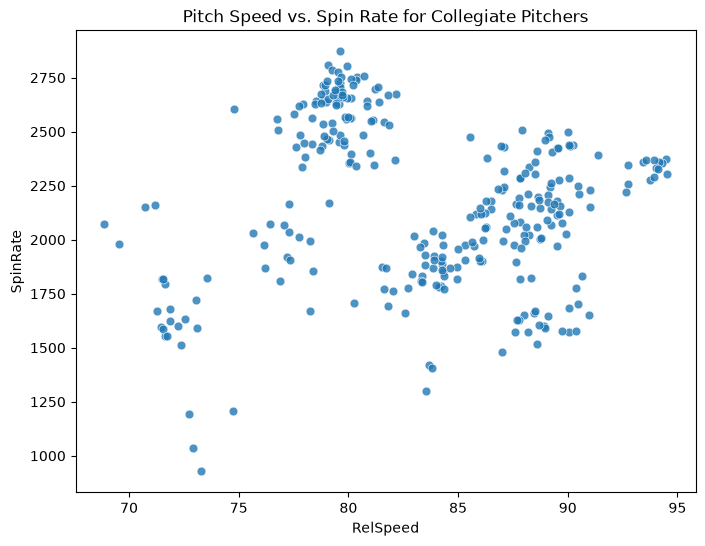

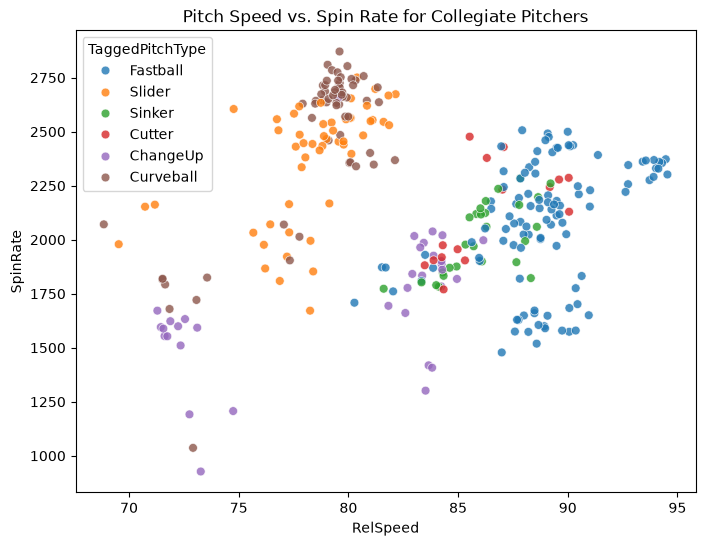

In [27]:
mat.figure(figsize = (8,6))
sds.scatterplot(x = 'RelSpeed', y = 'SpinRate', data = baseball_simple, s=40, alpha=0.8)
mat.title("Pitch Speed vs. Spin Rate for Collegiate Pitchers")
mat.show()

mat.figure(figsize = (8,6))
sds.scatterplot(x = 'RelSpeed', y = 'SpinRate', hue = 'TaggedPitchType', data = baseball_simple, s=40, alpha=0.8)
mat.title("Pitch Speed vs. Spin Rate for Collegiate Pitchers")
mat.show()


These charts display the speed and spin rates of 200-300 pitches thrown by D1 athletes.

While there is a very high level of nuance when distinguishing pitch types by the numbers, pitches can be broadly separated into 3 types with general relative trends:

- Fastballs (4-seam (just called Fastball), Sinker, Cutter): high velocity, high spin rate
- Offspeed pitches (just Changeup here, but also Splitter, very uncommon): medium velocity, low spin rate
- Breaking Balls (Slider, Curveball, Sweeper): low-medium velocity, high spin rate

We can see that encoding our second graph using pitch type (decided by GW managers) helps highlight these general clusters, and we can see that each pitch generally falls into a broad zone of what we'd expect its speed and spin rate pairing to be. This encoding could help an individual intuit the different categories that pitches can fall into and serves as a visual example for where those categories deviate.

Let's look at another chart, one that compares velocity across the different pitches thrown.

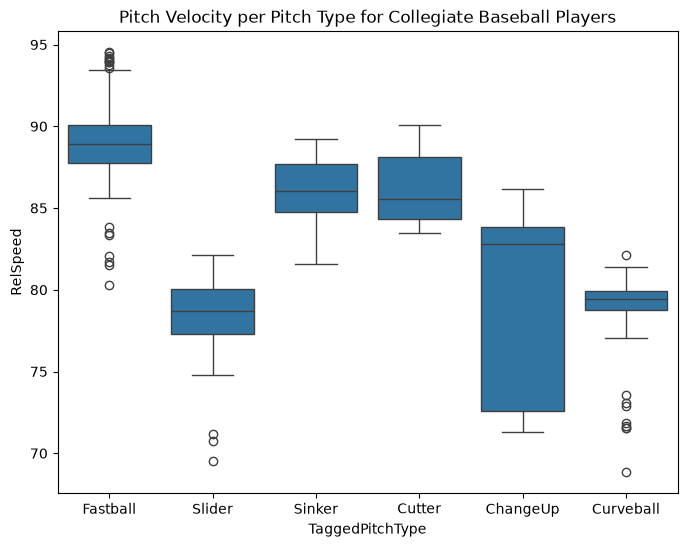

In [37]:
mat.figure(figsize=(8,6))
sds.boxplot(x="TaggedPitchType", y="RelSpeed", data=baseball_simple)
mat.title("Pitch Velocity per Pitch Type for Collegiate Baseball Players")
mat.show()

Here, I think a boxplot might be one of the best options to display our expectation for the speed of pitches. Here, we observe about what we would expect:

- The fastballs are the fastest, 4-seam being the highest velocity pitch of the three (this is commonly observed in almost every pitcher)
- Breaking balls are usually the slowest, pitches that focus more on their motion and movement likely won't have the same raw speed as others
- Major variation in changeup velocity, since it heavily depends on the speed of a specific pitcher's fastball

I chose this setup so we could see the explicit differences between pitch types and, again, so that an individual could intuit which categories pitches fall into based on their average velocity. However, this graph does suffer from a lack of nuance when it comes to evaluating college pitchers, as there is a high amount of variability between each type of pitch among different pitchers. For example, some pitchers base their game around a high-velo fastball and are likely to have less power on their other pitches, while others aim to keep their pitches in a similar speed zone so the break of certain pitches is more pronounced (and thus harder to pitch).

For our final plot, we will use the interactive library Altair. We'll be comparing horizontal break vs induced vertical break (two of our most important tools in identifying pitches) with some extra incodings to indicate pitch type and speed.

In [48]:
import altair as alt

alt.data_transformers.disable_max_rows()

alt.Chart(baseball_simple).mark_circle().encode(
    x='HorzBreak:Q',
    y='InducedVertBreak:Q',
    color='TaggedPitchType',
    size = alt.Size('RelSpeed:Q', scale = alt.Scale(zero = False, range = [20, 100])),
    tooltip=['TaggedPitchType','RelSpeed','HorzBreak','InducedVertBreak']
).interactive()

alt.Chart(...)

The chart visualizes the movement profiles of our pitches, with color displaying the type of pitch and size indicating how fast they were thrown. These help us easily identify which pitches have similar movement profiles (and which categories they fall into) as well as which ones are faster than others.

Here, we see a bit of clustering, which is helpful for us to successfully visualize where pitches should fall in terms of their movement profile. However, this chart suffers from a major issue: handedness of pitcher. The horizontal break of a pitcher directly corresponds to whether they are left or right handed; fastballs and changeups will move arm-side, while breaking balls will move glove-side. For example, we should expect positive horizontal break from a righty's fastball and negative horizontal break from lefty's fastball. I was hoping the graph would look relatively symmetric, but there likely isn't an even split of left handed and right handed pitchers in baseball, so our expectations of symmetry aren't exactly fulfilled. Furthermore, purely based on their movement profile (not factoring in speed or spin), two entirely different pitches can fall very close together on the chart since they're thrown by different handed pitchers.

Overall, this assignment was a fun way to explore the viability of certain visualizations as opposed to others, as well as experiment with some very creative Python libraries. I'm primarily an R user, but I can definitely see why Python is currently the industry standard for a versatile programming language.